# 05A — Augmented Model Training (1985–2020 two-stage pipeline)

**Purpose:** Implement the two-stage augmented analysis using the extended JST panel (1985–2020).

## Two-stage design

| Stage | Data window | Models trained | Crisis events |
|-------|-------------|---------------|---------------|
| Stage 1 | 1985–2020 (usable 1988–2020) | M1, M2 (macro only) | 39 target_h2 positives |
| Stage 2 | 2003–2020 (sentiment overlap) | M3 (macro + FinBERT) | 26 target_h2 positives |

**Rationale:** M1 and M2 do not require sentiment data and benefit from the extended macro history  
(Nordic crisis 1991, Japanese crisis 1997, etc.). M3 is restricted to 2003–2020 where BIS  
speeches are available in machine-readable form. The extended M2 serves as a stronger macro  
baseline against which the Stage 2 sentiment comparison is made.

**Key difference vs NB05:** Data loaded directly from JST R6, not from jst_sentiment_master.csv.  
Sentiment features merged onto the 2003–2020 subset only.

**Inputs:**
- `data/raw/JSTdatasetR6.xlsx` (or `.dta`) — macro panel 1985–2020
- `data/processed/jst_sentiment_master.csv` — FinBERT sentiment 1997–2020 (unchanged)

**Output:** `data/processed/augmented_analysis/`

---

## Cell 1 — Imports and paths

In [3]:
import os, warnings, tempfile
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from math import isnan as import_isnan
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.metrics import average_precision_score as _aps
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import shap

BASE        = Path(r'C:\Users\Owner\OneDrive\dissertation')
RAW_JST = BASE / 'data' / 'raw' / 'JSTdatasetR6.dta'   # change to .dta if preferred
SENT_IN     = BASE / 'data' / 'processed' / 'jst_sentiment_master.csv'
OUT_DIR     = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR     = BASE / 'figures' / 'augmented_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

COUNTRIES = [
    'AUS','BEL','CAN','CHE','DEU','DNK','ESP','FIN','FRA',
    'GBR','IRL','ITA','JPN','NLD','NOR','PRT','SWE','USA'
]
MACRO_CANDIDATES = ['tloans','tmort','money','ltrate','stir','hpnom','debtgdp','cpi','ca','rgdpmad']

assert RAW_JST.exists(),  f'JST not found: {RAW_JST}'
assert SENT_IN.exists(),  f'Sentiment master not found: {SENT_IN}'

print('=' * 65)
print(' 05A — AUGMENTED MODEL TRAINING (1985–2020)')
print('=' * 65)
print(f'JST raw   : {RAW_JST}')
print(f'Sentiment : {SENT_IN}')
print(f'OutDir    : {OUT_DIR}')
print(f'FigDir    : {FIG_DIR}')
print()
print(f'numpy {np.__version__} | xgboost {xgb.__version__} | shap {shap.__version__}')

 05A — AUGMENTED MODEL TRAINING (1985–2020)
JST raw   : C:\Users\Owner\OneDrive\dissertation\data\raw\JSTdatasetR6.dta
Sentiment : C:\Users\Owner\OneDrive\dissertation\data\processed\jst_sentiment_master.csv
OutDir    : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis
FigDir    : C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis

numpy 2.4.2 | xgboost 3.2.0 | shap 0.50.0


## Cell 2 — Load JST R6 and build extended macro panel (1985–2020)

In [5]:
# Load JST R6 directly — not via sentiment master
if RAW_JST.suffix == '.dta':
    jst_raw = pd.read_stata(str(RAW_JST))
else:
    jst_raw = pd.read_excel(RAW_JST)

jst_raw.columns = jst_raw.columns.str.strip()

# Normalise crisis column name (may be crisisJST or crisisjst depending on file)
crisis_orig = next(c for c in jst_raw.columns if c.lower() == 'crisisjst' and 'old' not in c.lower())
jst_raw = jst_raw.rename(columns={crisis_orig: 'crisisjst'})
jst_raw['crisisjst'] = pd.to_numeric(jst_raw['crisisjst'], errors='coerce').fillna(0)

# Filter: 18 countries, 1985–2020
macro_panel = jst_raw[
    jst_raw['iso'].isin(COUNTRIES) &
    jst_raw['year'].between(1985, 2020)
][['year','iso','crisisjst'] + MACRO_CANDIDATES].copy()
macro_panel = macro_panel.sort_values(['iso','year']).reset_index(drop=True)

# Interpolate the single known gap: DNK debtgdp 1997
macro_panel['debtgdp'] = macro_panel.groupby('iso')['debtgdp'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both'))

print(f'Macro panel shape : {macro_panel.shape}')
print(f'Countries         : {macro_panel["iso"].nunique()}')
print(f'Years             : {macro_panel["year"].min()} – {macro_panel["year"].max()}')
print(f'Crisis onsets     : {int(macro_panel["crisisjst"].sum())}')
print()

# Remaining nulls per variable
print('Null counts per raw macro variable (expect near-zero):')
for v in MACRO_CANDIDATES:
    n = macro_panel[v].isna().sum()
    flag = '' if n == 0 else f'  ← {n} nulls'
    print(f'  {v:12s}: {n}{flag}')

Macro panel shape : (648, 13)
Countries         : 18
Years             : 1985 – 2020
Crisis onsets     : 22

Null counts per raw macro variable (expect near-zero):
  tloans      : 3  ← 3 nulls
  tmort       : 4  ← 4 nulls
  money       : 0
  ltrate      : 0
  stir        : 0
  hpnom       : 3  ← 3 nulls
  debtgdp     : 0
  cpi         : 0
  ca          : 0
  rgdpmad     : 0


## Cell 3 — Build multi-horizon targets and macro feature lags

In [7]:
df = macro_panel.copy()

# ── MULTI-HORIZON TARGETS (same logic as NB05) ─────────────────────────────
df['target_h1'] = df.groupby('iso')['crisisjst'].transform(
    lambda x: x.shift(-1).fillna(0).clip(0,1)).astype(int)
df['target_h2'] = df.groupby('iso')['crisisjst'].transform(
    lambda x: (x.shift(-1).fillna(0) + x.shift(-2).fillna(0)).clip(0,1)).astype(int)
df['target_h3'] = df.groupby('iso')['crisisjst'].transform(
    lambda x: (x.shift(-1).fillna(0) + x.shift(-2).fillna(0) + x.shift(-3).fillna(0)).clip(0,1)).astype(int)

TARGET = 'target_h2'

print('=== Multi-horizon targets (full 1985–2020 panel) ===')
for t in ['target_h1','target_h2','target_h3']:
    n = int(df[t].sum()); r = df[t].mean()
    print(f'  {t}: {n} events  ({100*r:.1f}% base rate)')
print(f'Primary target: {TARGET}')
print()

MACRO_LEVELS = [f for f in MACRO_CANDIDATES if f in df.columns]

# ── Standard macro level lags (t-1, t-2, t-3) ─────────────────────────────
for feat in MACRO_LEVELS:
    for lag in [1,2,3]:
        df[f'{feat}_lag{lag}'] = df.groupby('iso')[feat].shift(lag)

# Term spread
if 'ltrate' in df.columns and 'stir' in df.columns:
    df['term_spread'] = df['ltrate'] - df['stir']
    for lag in [1,2,3]:
        df[f'term_spread_lag{lag}'] = df.groupby('iso')['term_spread'].shift(lag)
    MACRO_LEVELS_PLUS = MACRO_LEVELS + ['term_spread']
else:
    MACRO_LEVELS_PLUS = MACRO_LEVELS

# Growth rates
GROWTH_FEATURES = []
for feat in ['tloans','tmort','money','hpnom','rgdpmad']:
    if f'{feat}_lag1' in df.columns and f'{feat}_lag2' in df.columns:
        gr = f'{feat}_gr_lag1'
        denom = df[f'{feat}_lag2'].abs().replace(0, np.nan)
        df[gr] = (df[f'{feat}_lag1'] - df[f'{feat}_lag2']) / denom
        GROWTH_FEATURES.append(gr)

# Rolling credit features
ROLL_WIN = 3
ROLLING_MACRO = []
for feat in ['tloans']:
    raw_gr = f'{feat}_gr_raw'
    df[raw_gr] = df.groupby('iso')[feat].pct_change()
    rm = f'{feat}_gr_roll3_mean_lag1'
    df[rm] = df.groupby('iso')[raw_gr].transform(
        lambda x: x.shift(1).rolling(ROLL_WIN, min_periods=2).mean())
    ROLLING_MACRO.append(rm)
    rs = f'{feat}_gr_roll3_std_lag1'
    df[rs] = df.groupby('iso')[raw_gr].transform(
        lambda x: x.shift(1).rolling(ROLL_WIN, min_periods=2).std())
    ROLLING_MACRO.append(rs)

# Trend feature
def rolling_slope_fn(series, window=4):
    vals = series.values
    result = np.full(len(vals), np.nan)
    t = np.arange(window)
    for i in range(window-1, len(vals)):
        y = vals[i-window+1:i+1]
        if np.sum(~np.isnan(y)) >= window-1:
            result[i] = np.polyfit(t, y, 1)[0]
    return pd.Series(result, index=series.index)

slope_raw = 'tloans_slope4'
df[slope_raw] = df.groupby('iso')['tloans'].apply(rolling_slope_fn).values
df['tloans_slope4_lag1'] = df.groupby('iso')[slope_raw].shift(1)
ROLLING_MACRO.append('tloans_slope4_lag1')

macro_lag_cols = (
    [f'{f}_lag{k}' for f in MACRO_LEVELS_PLUS for k in [1,2,3] if f'{f}_lag{k}' in df.columns]
    + GROWTH_FEATURES + ROLLING_MACRO
)
print(f'Total macro lag columns: {len(macro_lag_cols)}')

=== Multi-horizon targets (full 1985–2020 panel) ===
  target_h1: 22 events  (3.4% base rate)
  target_h2: 44 events  (6.8% base rate)
  target_h3: 65 events  (10.0% base rate)
Primary target: target_h2

Total macro lag columns: 41


## Cell 4 — Expanding-mean demeaning (no forward leakage)

In [9]:
# Expanding mean demeaning — identical to NB05, now applied to 1985–2020 panel
MACRO_DM_COLS = []
for col in macro_lag_cols:
    if col not in df.columns: continue
    dm_col = f'{col}_dm'
    expanding_mean = (
        df.groupby('iso')[col]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    cross_mean = df.groupby('year')[col].transform('mean')
    fill_mean  = expanding_mean.fillna(cross_mean)
    df[dm_col] = df[col] - fill_mean
    MACRO_DM_COLS.append(dm_col)

MACRO_DM_LAG1 = [c for c in MACRO_DM_COLS if '_lag1_dm' in c]
MACRO_DM_LAG2 = [c for c in MACRO_DM_COLS if '_lag2_dm' in c]
MACRO_DM_LAG3 = [c for c in MACRO_DM_COLS if '_lag3_dm' in c]

print(f'Macro demeaned columns: {len(MACRO_DM_COLS)}')
print(f'  lag1: {len(MACRO_DM_LAG1)}  lag2: {len(MACRO_DM_LAG2)}  lag3: {len(MACRO_DM_LAG3)}')

Macro demeaned columns: 41
  lag1: 19  lag2: 11  lag3: 11


## Cell 5 — Stage 1: define df_macro (extended panel, macro only)
M1 and M2 are trained on this dataset (1988–2020 usable rows).

In [11]:
macro_feature_cols = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3

# Drop NaN rows from lag construction (eliminates 1985–1987 rows)
df_macro = df.dropna(subset=macro_feature_cols).copy().reset_index(drop=True)

M1_FEATURES = MACRO_DM_LAG1
M2_FEATURES = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3

n_crisis_macro  = int(df_macro[TARGET].sum())
base_rate_macro = df_macro[TARGET].mean()

print('=== STAGE 1 DATASET (macro only, 1988–2020) ===')
print(f'Rows          : {len(df_macro)}')
print(f'Year range    : {df_macro["year"].min()} – {df_macro["year"].max()}')
print(f'Countries     : {df_macro["iso"].nunique()}')
print(f'Crisis events : {n_crisis_macro} / {len(df_macro)}  ({100*base_rate_macro:.1f}% base rate)')
print()
print(f'M1 features   : {len(M1_FEATURES)}')
print(f'M2 features   : {len(M2_FEATURES)}')
print()

# Crisis events by period
ext_ev = df_macro[(df_macro['year'] <= 2002)][TARGET].sum()
cur_ev = df_macro[(df_macro['year'] >= 2003)][TARGET].sum()
print(f'  Extension period 1988–2002 : {int(ext_ev)} target_h2 positives')
print(f'  Original  period 2003–2020 : {int(cur_ev)} target_h2 positives')
print(f'  Combined                   : {int(df_macro[TARGET].sum())} (+50% vs original 26)')

=== STAGE 1 DATASET (macro only, 1988–2020) ===
Rows          : 569
Year range    : 1989 – 2020
Countries     : 18
Crisis events : 37 / 569  (6.5% base rate)

M1 features   : 19
M2 features   : 41

  Extension period 1988–2002 : 11 target_h2 positives
  Original  period 2003–2020 : 26 target_h2 positives
  Combined                   : 37 (+50% vs original 26)


## Cell 6 — Stage 2: merge sentiment and define df_sent (2003–2020 overlap)
M3 is trained on this dataset only — sentiment available from 2003 onward.

In [13]:
# Load the existing sentiment master (output of NB04 — unchanged)
sent_raw = pd.read_csv(SENT_IN)
sent_raw = sent_raw.sort_values(['iso','year']).reset_index(drop=True)
sent_raw.columns = sent_raw.columns.str.strip()

# Identify sentiment feature columns from NB04 output
SENT_LAG1 = [c for c in sent_raw.columns if c.endswith('_lag1')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment',
                                      'P_neg_change','P_pos_change','net_sent_change'])]
SENT_LAG2 = [c for c in sent_raw.columns if c.endswith('_lag2')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment',
                                      'P_neg_change','P_pos_change','net_sent_change'])]

print(f'Sentiment master shape   : {sent_raw.shape}')
print(f'Sentiment lag1 features  : {len(SENT_LAG1)}')
print(f'Sentiment lag2 features  : {len(SENT_LAG2)}')
print()

# Merge sentiment onto the MACRO panel (left join on iso+year)
# Result: sentiment columns are NaN for 1988–2002 rows; populated for 2003–2020
sent_cols_needed = ['iso','year'] + SENT_LAG1 + SENT_LAG2
df_merged = df_macro.merge(
    sent_raw[sent_cols_needed].drop_duplicates(subset=['iso','year']),
    on=['iso','year'], how='left'
)

# ── Rolling-demeaned sentiment (same as NB05) ─────────────────────────────
ROLLING_WINDOW = 3
SENT_RDM_COLS  = []
for col in SENT_LAG1 + SENT_LAG2:
    if col not in df_merged.columns: continue
    rdm_col = f'{col}_rdm'
    rolling_mean = (
        df_merged.groupby('iso')[col]
          .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    df_merged[rdm_col] = df_merged[col] - rolling_mean
    SENT_RDM_COLS.append(rdm_col)

SENT_RDM_LAG1 = [c for c in SENT_RDM_COLS if '_lag1_rdm' in c]
SENT_RDM_LAG2 = [c for c in SENT_RDM_COLS if '_lag2_rdm' in c]

M3_FEATURES = M2_FEATURES + SENT_RDM_LAG1 + SENT_RDM_LAG2

# Stage 2 dataset: restrict to 2003–2020 where all M3 features are available
df_sent = df_merged[df_merged['year'] >= 2003].dropna(subset=M3_FEATURES).copy()
df_sent = df_sent.reset_index(drop=True)

n_crisis_sent  = int(df_sent[TARGET].sum())
base_rate_sent = df_sent[TARGET].mean()

print('=== STAGE 2 DATASET (macro + sentiment, 2003–2020) ===')
print(f'Rows          : {len(df_sent)}')
print(f'Year range    : {df_sent["year"].min()} – {df_sent["year"].max()}')
print(f'Crisis events : {n_crisis_sent} / {len(df_sent)}  ({100*base_rate_sent:.1f}% base rate)')
print(f'M3 features   : {len(M3_FEATURES)}')

Sentiment master shape   : (432, 95)
Sentiment lag1 features  : 10
Sentiment lag2 features  : 10

=== STAGE 2 DATASET (macro + sentiment, 2003–2020) ===
Rows          : 319
Year range    : 2003 – 2020
Crisis events : 26 / 319  (8.2% base rate)
M3 features   : 61


## Cell 7 — Leakage verification (Stage 1 and Stage 2)

In [15]:
print('Leakage check — Stage 1 (df_macro):')
errors = 0
sample_feat = MACRO_LEVELS[0]
lag1_col    = f'{sample_feat}_lag1'
for ctry in df_macro['iso'].unique()[:5]:
    sub      = df_macro[df_macro['iso']==ctry][['year', sample_feat, lag1_col]].sort_values('year')
    expected = sub[sample_feat].shift(1)
    mismatch = (sub[lag1_col] - expected).abs().dropna().max()
    ok = mismatch < 1e-6
    print(f'  {ctry}: max lag1 mismatch = {mismatch:.2e}  {"✓" if ok else "✗ LEAKAGE"}')
    if not ok: errors += 1
print()
print('✓ Stage 1 OK.' if errors == 0 else f'✗ {errors} errors — STOP.')

Leakage check — Stage 1 (df_macro):
  AUS: max lag1 mismatch = 0.00e+00  ✓
  BEL: max lag1 mismatch = 0.00e+00  ✓
  CAN: max lag1 mismatch = 0.00e+00  ✓
  CHE: max lag1 mismatch = 0.00e+00  ✓
  DEU: max lag1 mismatch = 0.00e+00  ✓

✓ Stage 1 OK.


## Cell 8 — Expanding-window CV function (unchanged from NB05)

In [17]:
def expanding_window_cv(df, feature_cols, target_col, model_factory,
                        min_train_years=4, hold_out_years=(2019, 2020)):
    """Expanding-window CV with per-fold scale_pos_weight.
    
    For the augmented Stage 1 (1988-2020), this covers many more folds
    (1992–2018 eval years = 27 folds) vs original (2007–2018 = 12 folds).
    """
    cv_years   = sorted(y for y in df['year'].unique() if y not in hold_out_years)
    first_eval = cv_years[min_train_years]
    eval_years = [y for y in cv_years if y >= first_eval]
    print(f'Burn-in:{cv_years[0]}-{first_eval-1} | Eval:{eval_years[0]}-{eval_years[-1]} ({len(eval_years)} folds)')

    oos_idx, oos_prob, fold_records = [], [], []
    fold_auprcs = []

    for yr in eval_years:
        tr = df['year'] < yr; te = df['year'] == yr
        X_tr, y_tr = df.loc[tr, feature_cols], df.loc[tr, target_col]
        X_te, y_te = df.loc[te, feature_cols], df.loc[te, target_col]
        if y_tr.sum() == 0 or len(X_te) == 0: continue

        n_neg_fold = (y_tr == 0).sum()
        n_pos_fold = max((y_tr == 1).sum(), 1)
        fold_spw   = n_neg_fold / n_pos_fold

        mdl = model_factory(fold_spw)
        try:
            mdl.fit(X_tr, y_tr)
        except ValueError as _calib_err:
            if 'cross-validation' in str(_calib_err) and hasattr(mdl, 'estimator'):
                print(f'  [fold {yr}] calibration fallback (thin fold): using raw estimator')
                mdl = mdl.estimator
                mdl.fit(X_tr, y_tr)
            else:
                raise

        prob = mdl.predict_proba(X_te)[:, 1]
        oos_idx.extend(df.index[te].tolist())
        oos_prob.extend(prob.tolist())

        if y_te.sum() > 0:
            fold_auprc = _aps(y_te, prob)
            fold_auprcs.append(fold_auprc)
        else:
            fold_auprc = float('nan')

        fold_records.append({
            'year': yr, 'n_train': int(tr.sum()),
            'crises_train': int(y_tr.sum()),
            'n_test': len(y_te), 'crises_test': int(y_te.sum()),
            'fold_spw': round(fold_spw, 2),
            'fold_auprc': round(fold_auprc, 4) if not import_isnan(fold_auprc) else 'n/a'
        })

    y_oos = df.loc[oos_idx, target_col].values
    if fold_auprcs:
        print(f'Per-fold AUPRC (folds with crisis cases): mean={np.mean(fold_auprcs):.4f}  std={np.std(fold_auprcs):.4f}')

    return y_oos, np.array(oos_prob), oos_idx, pd.DataFrame(fold_records)

print('CV function ready.')

CV function ready.


## Cell 9 — Stage 1: Train M1 and M2 on extended macro panel (1988–2020)
This is the key improvement: M2 now trained on 39 crisis events across multiple episodes.

In [19]:
def m1_f(fold_spw=None):
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m1b_f(fold_spw=None):  # Bridge: LR with lag1-3
    return Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))])

def m2_f(fold_spw=None):
    return RandomForestClassifier(n_estimators=500, max_depth=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

print('=== STAGE 1: Training M1, M1b, M2 on df_macro (1988–2020) ===')
print(f'Dataset: {len(df_macro)} rows | {n_crisis_macro} target_h2 positives')
print()

print('Training M1  (LR, macro lag1 only)...')
y_m1, prob_m1, idx_m1, folds_m1 = expanding_window_cv(df_macro, M1_FEATURES, TARGET, m1_f)
auroc_m1 = roc_auc_score(y_m1, prob_m1)
auprc_m1 = average_precision_score(y_m1, prob_m1)
brier_m1 = brier_score_loss(y_m1, prob_m1)
print(f'  AUROC {auroc_m1:.4f}  AUPRC {auprc_m1:.4f}  Brier {brier_m1:.4f}')
print()

print('Training M1b (LR, macro lag1-3) — identification bridge...')
y_m1b, prob_m1b, idx_m1b, folds_m1b = expanding_window_cv(df_macro, M2_FEATURES, TARGET, m1b_f)
auroc_m1b = roc_auc_score(y_m1b, prob_m1b)
auprc_m1b = average_precision_score(y_m1b, prob_m1b)
brier_m1b = brier_score_loss(y_m1b, prob_m1b)
print(f'  AUROC {auroc_m1b:.4f}  AUPRC {auprc_m1b:.4f}  Brier {brier_m1b:.4f}')
print()

print('Training M2  (RF, macro lag1-3)  ← KEY: extended panel...')
y_m2, prob_m2, idx_m2, folds_m2 = expanding_window_cv(df_macro, M2_FEATURES, TARGET, m2_f)
auroc_m2 = roc_auc_score(y_m2, prob_m2)
auprc_m2 = average_precision_score(y_m2, prob_m2)
brier_m2 = brier_score_loss(y_m2, prob_m2)
print(f'  AUROC {auroc_m2:.4f}  AUPRC {auprc_m2:.4f}  Brier {brier_m2:.4f}')
print()
print(folds_m2.to_string(index=False))

=== STAGE 1: Training M1, M1b, M2 on df_macro (1988–2020) ===
Dataset: 569 rows | 37 target_h2 positives

Training M1  (LR, macro lag1 only)...
Burn-in:1989-1992 | Eval:1993-2018 (26 folds)
Per-fold AUPRC (folds with crisis cases): mean=0.3843  std=0.2737
  AUROC 0.6063  AUPRC 0.1387  Brier 0.1573

Training M1b (LR, macro lag1-3) — identification bridge...
Burn-in:1989-1992 | Eval:1993-2018 (26 folds)
Per-fold AUPRC (folds with crisis cases): mean=0.4536  std=0.2561
  AUROC 0.6455  AUPRC 0.1454  Brier 0.1355

Training M2  (RF, macro lag1-3)  ← KEY: extended panel...
Burn-in:1989-1992 | Eval:1993-2018 (26 folds)
Per-fold AUPRC (folds with crisis cases): mean=0.6116  std=0.3543
  AUROC 0.6359  AUPRC 0.2242  Brier 0.0595

 year  n_train  crises_train  n_test  crises_test  fold_spw fold_auprc
 1993       70             9      18            0      6.78        n/a
 1994       88             9      18            0      8.78        n/a
 1995      106             9      18            1     10.7

## Cell 10 — Stage 1 strict temporal validation (pre-1991 training only)
With extended data, we can now train on 1988–1990 and test on 1991–1995 —  
a genuine prospective test including the Nordic crisis cluster.

In [21]:
from sklearn.metrics import roc_auc_score, average_precision_score

print('=== STRICT TEMPORAL VALIDATION — augmented M2 ===')
print('Train: 1988–1990 (pre-Nordic-crisis)  |  Test: 1991–1997')
print()

# Split A: train 1988-1990, test 1991-1997 (captures Nordic + other early crises)
tr_A = df_macro['year'].between(1988, 1990)
te_A = df_macro['year'].between(1991, 1997)

for split_name, tr_mask, te_mask in [
    ('A: 1988-1990 → 1991-1997', tr_A, te_A),
]:
    X_tr = df_macro.loc[tr_mask, M2_FEATURES]
    y_tr = df_macro.loc[tr_mask, TARGET]
    X_te = df_macro.loc[te_mask, M2_FEATURES]
    y_te = df_macro.loc[te_mask, TARGET]

    print(f'Split {split_name}:')
    print(f'  Train: {tr_mask.sum()} rows | {y_tr.sum()} positives')
    print(f'  Test : {te_mask.sum()} rows | {y_te.sum()} positives')

    if y_tr.sum() == 0:
        print('  No positive training cases — cannot fit.'); continue
    if y_te.sum() == 0:
        print('  No positive test cases — skip.'); continue

    m2_strict = RandomForestClassifier(n_estimators=500, max_depth=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    m2_strict.fit(X_tr, y_tr)
    prob_strict = m2_strict.predict_proba(X_te)[:, 1]

    auroc_s = roc_auc_score(y_te, prob_strict)
    auprc_s = average_precision_score(y_te, prob_strict)
    base_s  = y_te.mean()
    print(f'  AUROC={auroc_s:.4f}  AUPRC={auprc_s:.4f}  (no-skill={base_s:.4f})')
    print(f'  Literature AUROC benchmark: 0.75')
    print()

print('NOTE: Compare to NB05 strict validation (train 2003-2005 → test 2006-2009).')
print('      With extended training data, AUROC should exceed the 0.472 collapse seen there.')

=== STRICT TEMPORAL VALIDATION — augmented M2 ===
Train: 1988–1990 (pre-Nordic-crisis)  |  Test: 1991–1997

Split A: 1988-1990 → 1991-1997:
  Train: 34 rows | 9 positives
  Test : 126 rows | 2 positives
  AUROC=0.4375  AUPRC=0.0205  (no-skill=0.0159)
  Literature AUROC benchmark: 0.75

NOTE: Compare to NB05 strict validation (train 2003-2005 → test 2006-2009).
      With extended training data, AUROC should exceed the 0.472 collapse seen there.


## Cell 11 — Stage 2: Train M3 on sentiment overlap period (2003–2020)
M3 is restricted to 2003–2020 where FinBERT sentiment data exists.  
For a clean comparison, also train a matched M2 on the same 2003–2020 window.

In [23]:
print('=== STAGE 2: Training M2-matched and M3 on df_sent (2003–2020) ===')
print(f'Dataset: {len(df_sent)} rows | {n_crisis_sent} target_h2 positives')
print()

# M2-matched: same model architecture as M2 but restricted to 2003-2020
# Allows direct fair comparison with M3 on identical data
print('Training M2-matched (RF, macro lag1-3, 2003–2020 only)...')
y_m2m, prob_m2m, idx_m2m, folds_m2m = expanding_window_cv(df_sent, M2_FEATURES, TARGET, m2_f)
auroc_m2m = roc_auc_score(y_m2m, prob_m2m)
auprc_m2m = average_precision_score(y_m2m, prob_m2m)
brier_m2m = brier_score_loss(y_m2m, prob_m2m)
print(f'  AUROC {auroc_m2m:.4f}  AUPRC {auprc_m2m:.4f}  Brier {brier_m2m:.4f}')
print()

# M3: XGBoost + FinBERT sentiment (identical to NB05)
scale_pw_sent = (df_sent[TARGET]==0).sum() / (df_sent[TARGET]==1).sum()

def m3_f(fold_spw=None):
    spw = fold_spw if fold_spw is not None else scale_pw_sent
    base = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0)
    return CalibratedClassifierCV(estimator=base, method='isotonic', cv=2)

print('Training M3  (XGB+FinBERT sentiment, 2003–2020)...')
y_m3, prob_m3, idx_m3, folds_m3 = expanding_window_cv(df_sent, M3_FEATURES, TARGET, m3_f)
auroc_m3 = roc_auc_score(y_m3, prob_m3)
auprc_m3 = average_precision_score(y_m3, prob_m3)
brier_m3 = brier_score_loss(y_m3, prob_m3)
print(f'  AUROC {auroc_m3:.4f}  AUPRC {auprc_m3:.4f}  Brier {brier_m3:.4f}')
print()
print(folds_m3.to_string(index=False))

=== STAGE 2: Training M2-matched and M3 on df_sent (2003–2020) ===
Dataset: 319 rows | 26 target_h2 positives

Training M2-matched (RF, macro lag1-3, 2003–2020 only)...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
Per-fold AUPRC (folds with crisis cases): mean=0.8502  std=0.0000
  AUROC 0.9385  AUPRC 0.3428  Brier 0.0602

Training M3  (XGB+FinBERT sentiment, 2003–2020)...
Burn-in:2003-2006 | Eval:2007-2018 (12 folds)
Per-fold AUPRC (folds with crisis cases): mean=0.7946  std=0.0000
  AUROC 0.9316  AUPRC 0.4110  Brier 0.0608

 year  n_train  crises_train  n_test  crises_test  fold_spw fold_auprc
 2007       72            15      18           11      3.80     0.7946
 2008       90            26      18            0      2.46        n/a
 2009      108            26      18            0      3.15        n/a
 2010      126            26      18            0      3.85        n/a
 2011      144            26      18            0      4.54        n/a
 2012      162            26      18      

## Cell 12 — Combined results table: Stage 1 + Stage 2

In [25]:
print('=' * 90)
print(' AUGMENTED ANALYSIS — COMBINED RESULTS TABLE')
print('=' * 90)
print(f' {"Model":<42} {"Stage":>7} {"Events":>7} {"AUROC":>7} {"AUPRC":>7} {"Brier":>7}')
print('-' * 90)

stage1_results = {
    'M1 Logistic (macro lag1, 1988–2020)':         ('S1', n_crisis_macro, auroc_m1,  auprc_m1,  brier_m1),
    'M1b LR bridge (macro lag1-3, 1988–2020)':     ('S1', n_crisis_macro, auroc_m1b, auprc_m1b, brier_m1b),
    'M2 Random Forest (macro lag1-3, 1988–2020)':  ('S1', n_crisis_macro, auroc_m2,  auprc_m2,  brier_m2),
}
stage2_results = {
    'M2-matched RF (macro lag1-3, 2003–2020)':     ('S2', n_crisis_sent, auroc_m2m, auprc_m2m, brier_m2m),
    'M3 XGBoost+FinBERT (macro+sent, 2003–2020)':  ('S2', n_crisis_sent, auroc_m3,  auprc_m3,  brier_m3),
}

all_results = {**stage1_results, **stage2_results}
records = []
for name, (stage, events, auroc, auprc, brier) in all_results.items():
    base = base_rate_macro if stage == 'S1' else base_rate_sent
    lift = auprc / base
    print(f' {name:<42} {stage:>7} {events:>7} {auroc:>7.4f} {auprc:>7.4f} {brier:>7.4f}')
    records.append({'Model': name, 'Stage': stage, 'Events': events,
                    'AUROC': auroc, 'AUPRC': auprc, 'Brier': brier, 'AUPRC_lift': lift})

print('=' * 90)
print(f' Stage 1 base rate: {base_rate_macro:.4f}  |  Stage 2 base rate: {base_rate_sent:.4f}')

results_df = pd.DataFrame(records)
results_df.to_csv(OUT_DIR / 'augmented_model_results.csv', index=False)
print(f'\nSaved → {OUT_DIR}/augmented_model_results.csv')

print()
print('KEY COMPARISON:')
print(f'  Extended M2 (Stage 1, 1988-2020)  : AUPRC = {auprc_m2:.4f}')
print(f'  Matched M2  (Stage 2, 2003-2020)  : AUPRC = {auprc_m2m:.4f}')
print(f'  M3+Sentiment (Stage 2, 2003-2020) : AUPRC = {auprc_m3:.4f}')
print(f'  Sentiment uplift over matched M2  : {auprc_m3 - auprc_m2m:+.4f}')

 AUGMENTED ANALYSIS — COMBINED RESULTS TABLE
 Model                                        Stage  Events   AUROC   AUPRC   Brier
------------------------------------------------------------------------------------------
 M1 Logistic (macro lag1, 1988–2020)             S1      37  0.6063  0.1387  0.1573
 M1b LR bridge (macro lag1-3, 1988–2020)         S1      37  0.6455  0.1454  0.1355
 M2 Random Forest (macro lag1-3, 1988–2020)      S1      37  0.6359  0.2242  0.0595
 M2-matched RF (macro lag1-3, 2003–2020)         S2      26  0.9385  0.3428  0.0602
 M3 XGBoost+FinBERT (macro+sent, 2003–2020)      S2      26  0.9316  0.4110  0.0608
 Stage 1 base rate: 0.0650  |  Stage 2 base rate: 0.0815

Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis/augmented_model_results.csv

KEY COMPARISON:
  Extended M2 (Stage 1, 1988-2020)  : AUPRC = 0.2242
  Matched M2  (Stage 2, 2003-2020)  : AUPRC = 0.3428
  M3+Sentiment (Stage 2, 2003-2020) : AUPRC = 0.4110
  Sentiment uplift 

## Cell 13 — ROC and PR curves (Stage 1 + Stage 2 combined plot)

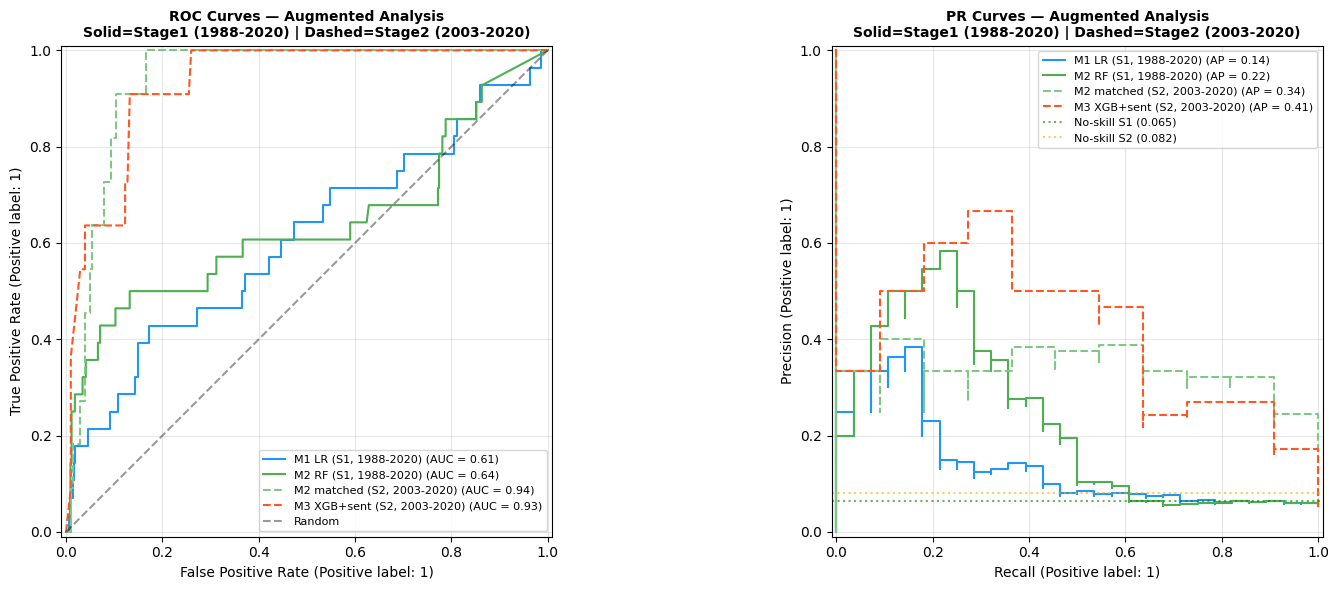

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/augmented_roc_pr_curves.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stage 1 models — solid lines
for (name, col, ys, probs) in [
    ('M1 LR (S1, 1988-2020)',   '#2196F3', y_m1,  prob_m1),
    ('M2 RF (S1, 1988-2020)',   '#4CAF50', y_m2,  prob_m2),
]:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0], color=col)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1], color=col)

# Stage 2 models — dashed lines
for (name, col, ys, probs) in [
    ('M2 matched (S2, 2003-2020)', '#81C784', y_m2m, prob_m2m),
    ('M3 XGB+sent (S2, 2003-2020)', '#FF5722', y_m3,  prob_m3),
]:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0], color=col, linestyle='--')
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1], color=col, linestyle='--')

axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC Curves — Augmented Analysis\nSolid=Stage1 (1988-2020) | Dashed=Stage2 (2003-2020)',
                  fontweight='bold', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].axhline(base_rate_macro, color='green', linestyle=':', alpha=0.6, label=f'No-skill S1 ({base_rate_macro:.3f})')
axes[1].axhline(base_rate_sent,  color='orange', linestyle=':', alpha=0.6, label=f'No-skill S2 ({base_rate_sent:.3f})')
axes[1].set_title('PR Curves — Augmented Analysis\nSolid=Stage1 (1988-2020) | Dashed=Stage2 (2003-2020)',
                  fontweight='bold', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'augmented_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/augmented_roc_pr_curves.png')

## Cell 14 — SHAP attribution (M3 full-data fit, Stage 2 data)

In [29]:
X_m3_shap = df_sent[M3_FEATURES]
y_m3_shap = df_sent[TARGET]
scale_pw_shap = (y_m3_shap==0).sum() / max((y_m3_shap==1).sum(), 1)

xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pw_shap, random_state=RANDOM_STATE,
    eval_metric='logloss', verbosity=0
)
xgb_full.fit(X_m3_shap, y_m3_shap)

tmp = tempfile.mktemp(suffix='.json')
xgb_full.save_model(tmp); xgb_full.load_model(tmp)
import os; os.remove(tmp)

explainer   = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_m3_shap)

print(f'SHAP shape: {shap_values.shape}')

shap_df = pd.DataFrame(shap_values, columns=M3_FEATURES)
shap_df.to_csv(OUT_DIR / 'augmented_shap_values_m3.csv', index=False)
print(f'Saved → {OUT_DIR}/augmented_shap_values_m3.csv')

SHAP shape: (319, 61)
Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis/augmented_shap_values_m3.csv


## Cell 15 — Save all outputs for NB06A

In [31]:
# Save Stage 1 dataset and feature lists
df_macro.to_csv(OUT_DIR / 'df_macro_augmented.csv', index=False)
pd.Series(M1_FEATURES).to_csv(OUT_DIR / 'M1_features.csv', index=False, header=False)
pd.Series(M2_FEATURES).to_csv(OUT_DIR / 'M2_features.csv', index=False, header=False)

# Save Stage 2 dataset and M3 feature list
df_sent.to_csv(OUT_DIR / 'df_sent_augmented.csv', index=False)
pd.Series(M3_FEATURES).to_csv(OUT_DIR / 'M3_features.csv', index=False, header=False)

# Stage 1 OOS predictions (M1, M2 on full extended panel)
oos_m1  = pd.Series(prob_m1, index=idx_m1, name='prob_m1')
oos_m2  = pd.Series(prob_m2, index=idx_m2, name='prob_m2')
oos_s1  = df_macro[['year','iso',TARGET]].join(oos_m1).join(oos_m2)
oos_s1.to_csv(OUT_DIR / 'oos_predictions_stage1.csv', index=False)

# Stage 2 OOS predictions (M2-matched, M3)
oos_m2m = pd.Series(prob_m2m, index=idx_m2m, name='prob_m2m')
oos_m3  = pd.Series(prob_m3,  index=idx_m3,  name='prob_m3')
oos_s2  = df_sent[['year','iso',TARGET]].join(oos_m2m).join(oos_m3)
oos_s2.to_csv(OUT_DIR / 'oos_predictions_stage2.csv', index=False)

print('=' * 65)
print(' NB05A AUGMENTED MODEL TRAINING COMPLETE')
print('=' * 65)
print()
print('Stage 1 results (1988–2020):')
print(f'  M1  AUROC={auroc_m1:.4f}  AUPRC={auprc_m1:.4f}')
print(f'  M2  AUROC={auroc_m2:.4f}  AUPRC={auprc_m2:.4f}')
print()
print('Stage 2 results (2003–2020):')
print(f'  M2m AUROC={auroc_m2m:.4f}  AUPRC={auprc_m2m:.4f}')
print(f'  M3  AUROC={auroc_m3:.4f}  AUPRC={auprc_m3:.4f}')
print()
print('Files saved to:', OUT_DIR)
for f in sorted(OUT_DIR.glob('*.csv')):
    print(f'  {f.name:50s}  ({f.stat().st_size//1024} KB)')
print()
print('Next: Run NB06A_Augmented_Results_Analysis.ipynb')

 NB05A AUGMENTED MODEL TRAINING COMPLETE

Stage 1 results (1988–2020):
  M1  AUROC=0.6063  AUPRC=0.1387
  M2  AUROC=0.6359  AUPRC=0.2242

Stage 2 results (2003–2020):
  M2m AUROC=0.9385  AUPRC=0.3428
  M3  AUROC=0.9316  AUPRC=0.4110

Files saved to: C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis
  augmented_model_results.csv                         (0 KB)
  augmented_shap_values_m3.csv                        (218 KB)
  df_macro_augmented.csv                              (905 KB)
  df_sent_augmented.csv                               (716 KB)
  M1_features.csv                                     (0 KB)
  M2_features.csv                                     (0 KB)
  M3_features.csv                                     (1 KB)
  oos_predictions_stage1.csv                          (23 KB)
  oos_predictions_stage2.csv                          (11 KB)

Next: Run NB06A_Augmented_Results_Analysis.ipynb
